In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [4]:
 df["Income"]=df["Income"].fillna(df["Income"].median())

In [5]:
df.columns
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df["Age"]=2026-df["Year_Birth"]

In [7]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [8]:
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [10]:
df["Total_Spend"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [11]:
df["Education"].value_counts()
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"postgraduate",
    "PhD":"postgraduate"
})
df["Marital_Status"].value_counts()
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Alone":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spend,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [13]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
columns_to_drop=cols+spending_cols
df_cleaned=df.drop(columns_to_drop,axis=1)

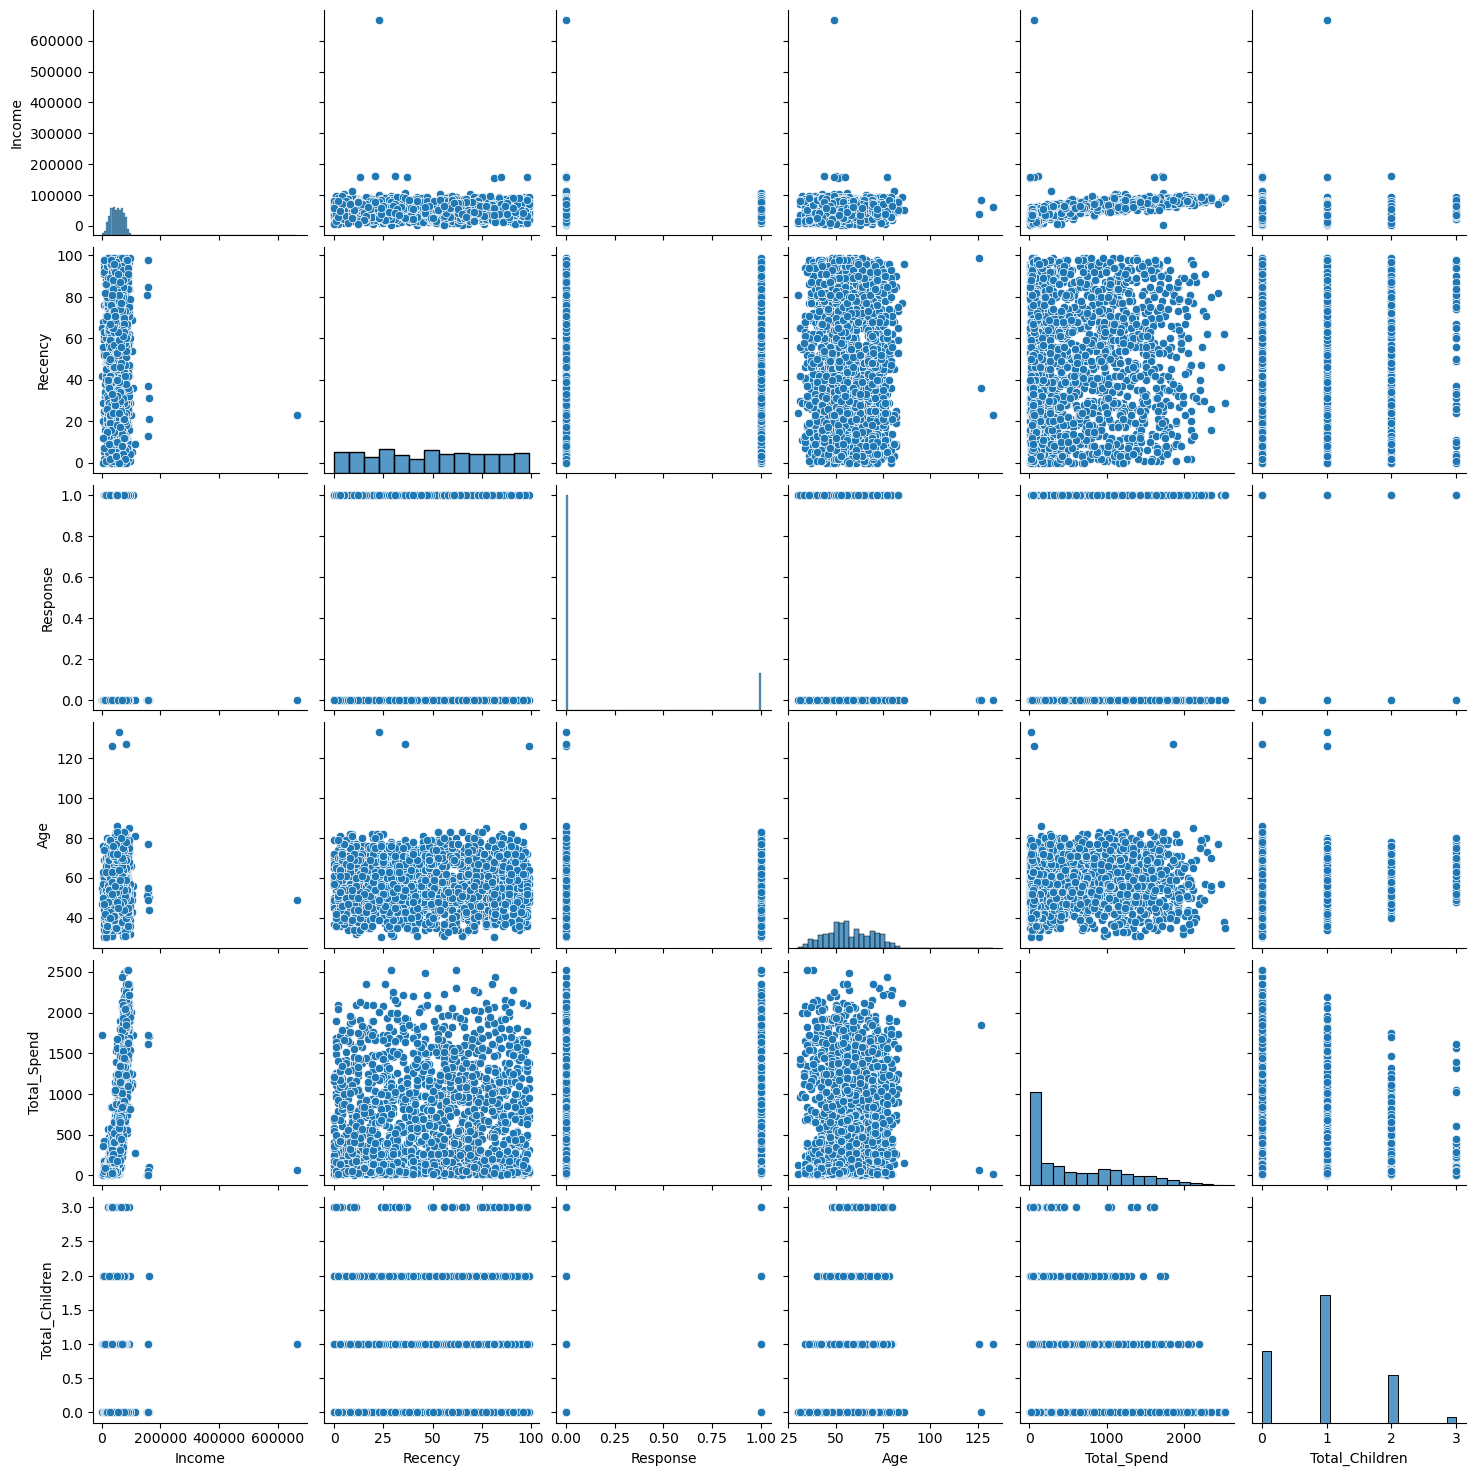

In [14]:
cols=["Income","Recency","Response","Age","Total_Spend","Total_Children"]
#reltive plot of sum feature
sns.pairplot(df_cleaned[cols])

In [15]:
#remove_outliers
print("data size with outlier",len(df_cleaned))
df_cleaned=df_cleaned[ (df_cleaned["Age"] <90)]
df_cleaned=df_cleaned[ (df_cleaned["Income"] <600_000)]
print("data size without outlier",len(df_cleaned))

data size without outlier 2240
data size with outlier 2236


In [16]:
#heatmap
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

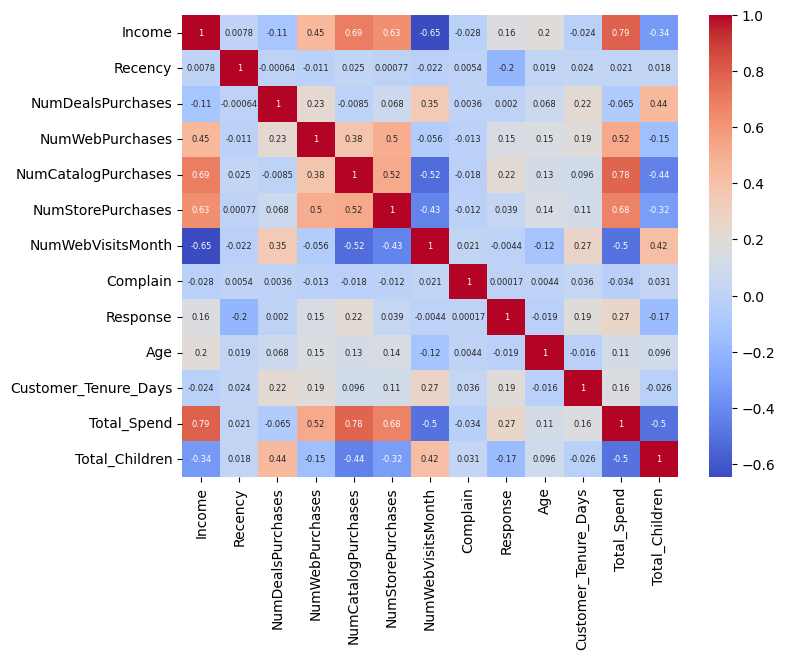

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)


In [18]:
from sklearn.preprocessing import OneHotEncoder

In [19]:
ohe=OneHotEncoder()

In [20]:
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [21]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [22]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [23]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spend,Total_Children,Education_Graduate,Education_Undergraduate,Education_postgraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,0.0,1.0,0.0,1.0


In [24]:
from sklearn.preprocessing import StandardScaler
x=df_encoded

In [25]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [26]:
x_scaled.shape

(2236, 18)

In [27]:
from sklearn.decomposition import PCA

In [28]:
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0.92, '3d projection')

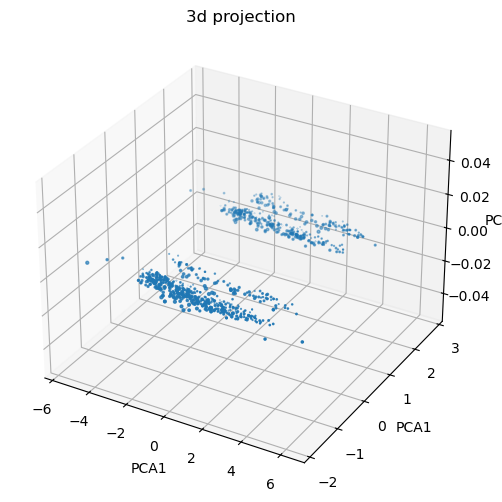

In [29]:
fig=plt.figure(figsize=(18,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA1")
ax.set_zlabel("PCA1")
ax.set_title("3d projection")

In [30]:
#naaylise k value
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [31]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [32]:
optimal_k=knee.elbow

In [33]:
print("best_",optimal_k)

best_ 4


Text(0, 0.5, 'WCSS')

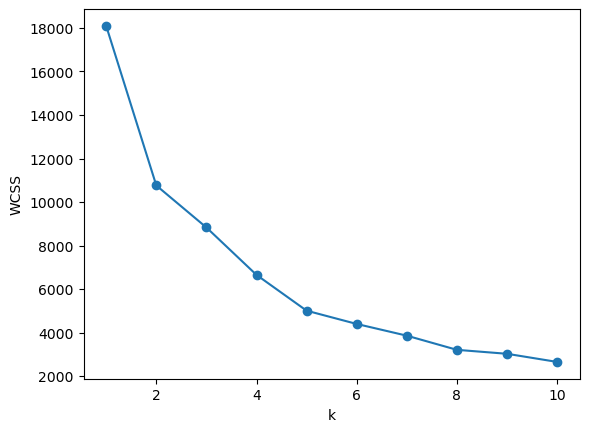

In [34]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")

In [35]:
from sklearn.metrics import silhouette_score

In [36]:
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)

Text(0, 0.5, 'silhoutee_scores')

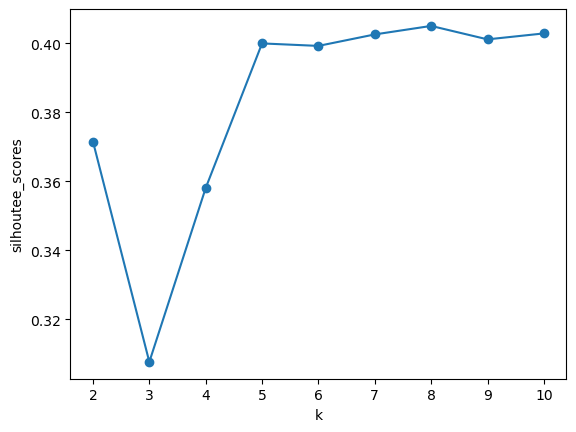

In [37]:
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("k")
plt.ylabel("silhoutee_scores")

Text(0, 0.5, 'silotte score')

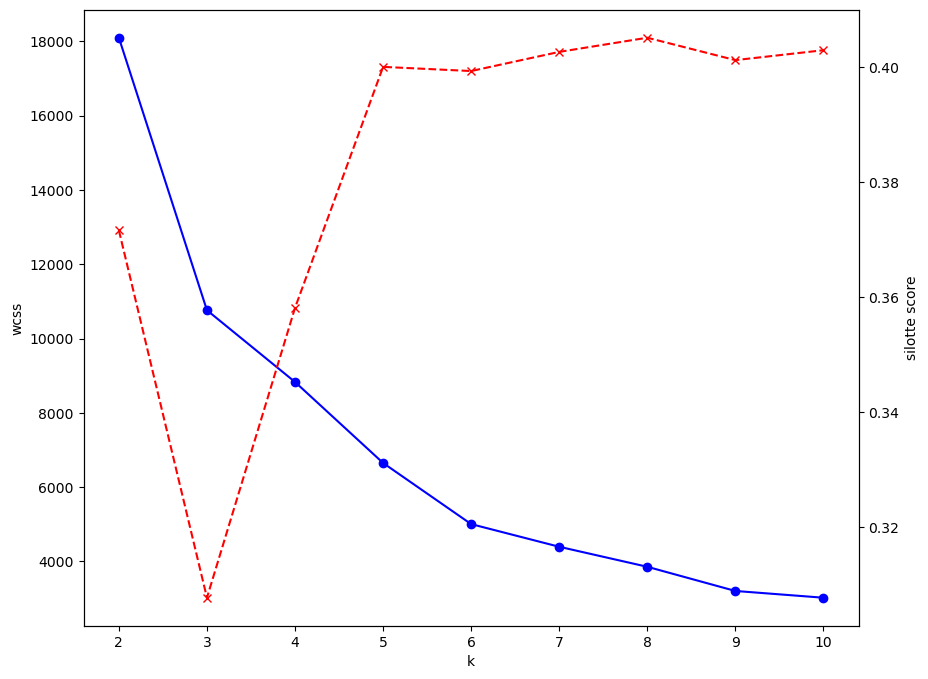

In [42]:
#combine plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,8))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color="red",linestyle="--")
ax2.set_ylabel("silotte score")

In [46]:
#clustering 
kmenas=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


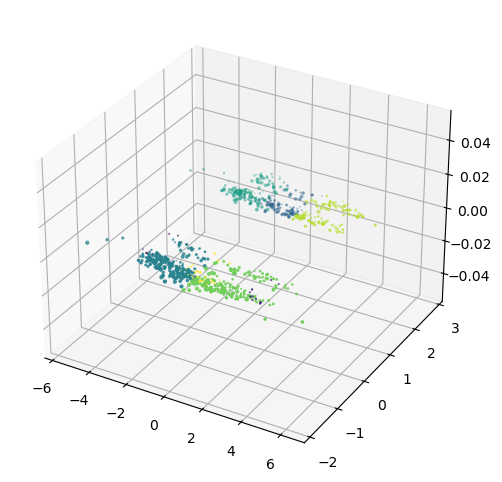

In [49]:
fig=plt.figure(figsize=(18,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [50]:
#aglomartive clustering 
from sklearn.cluster import AgglomerativeClustering

In [53]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(x_pca)

C:\ProgramData\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


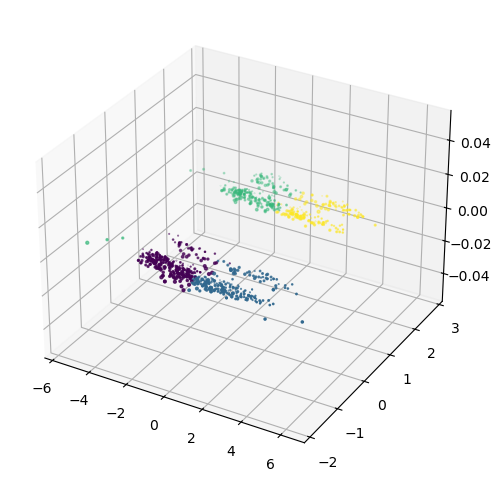

In [54]:
fig=plt.figure(figsize=(18,6))
ax=fig.add_subplot(111,projection="3d")
plt.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

In [56]:
#characterzitionb of cluster 
df_cleaned["labels"]=labels_agg

<Axes: xlabel='labels', ylabel='count'>

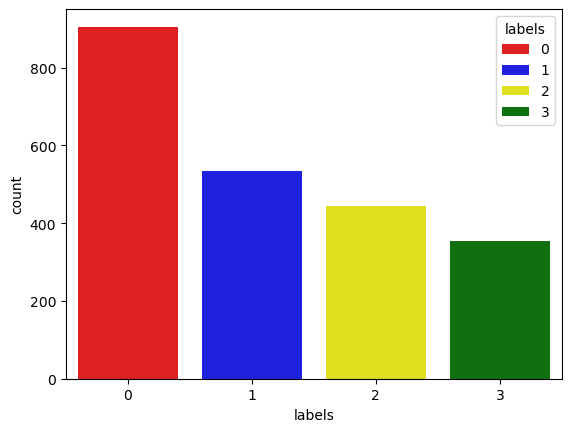

In [64]:
pal=["red","blue","yellow","green"]
sns.countplot(x=df_cleaned["labels"],palette=pal,hue=df_cleaned["labels"])

<Axes: xlabel='Total_Spend', ylabel='Income'>

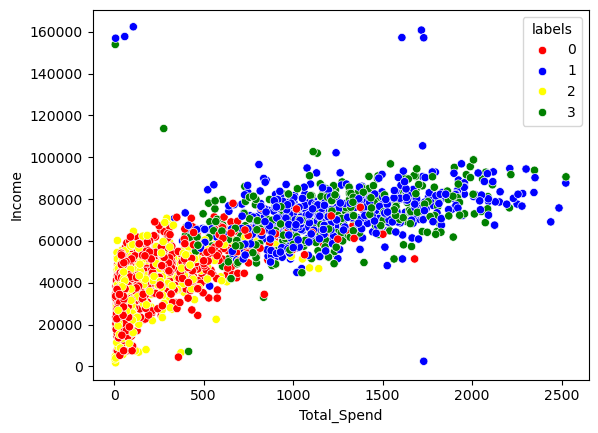

In [71]:
sns.scatterplot(x=df_cleaned["Total_Spend"],y=df_cleaned["Income"],hue=df_cleaned["labels"],palette=pal)

In [76]:
#cluster summery
x["labels"]=df_cleaned["labels"]

In [78]:
cluster_summary=x.groupby("labels").mean()
print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
labels                                                                
0       39680.580110  48.914917           2.594475         3.153591   
1       72808.445693  49.202247           1.958801         5.687266   
2       36960.143018  48.319820           2.594595         2.713964   
3       70722.681303  50.504249           1.855524         5.790368   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
labels                                                                        
0                  0.969061           4.143646           6.307182  0.011050   
1                  5.498127           8.659176           3.580524  0.005618   
2                  0.837838           3.623874           6.659910  0.011261   
3                  5.014164           8.430595           3.728045  0.005666   

        Response        Age  Customer_Tenure_Days  Total_Spend  \
labels                          

In [2]:
6

SyntaxError: invalid syntax (466840538.py, line 1)

In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())



ModuleNotFoundError: No module named 'torch'